# 04-decision-tree-diabetes

## Goal

In this notebook, we build the decision tree model using the cleaned dataset from the EDA notebook.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [16]:
df = pd.read_csv('../data/processed/diabetes_clean.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [18]:
criteria = ['gini', 'entropy', 'log_loss']
results = []

for c in criteria:
    model = DecisionTreeClassifier(criterion=c, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({'criterion': c, 'accuracy': acc})

results_df = pd.DataFrame(results)
results_df

,criterion,accuracy
0,gini,0.681818
1,entropy,0.675325
2,log_loss,0.675325


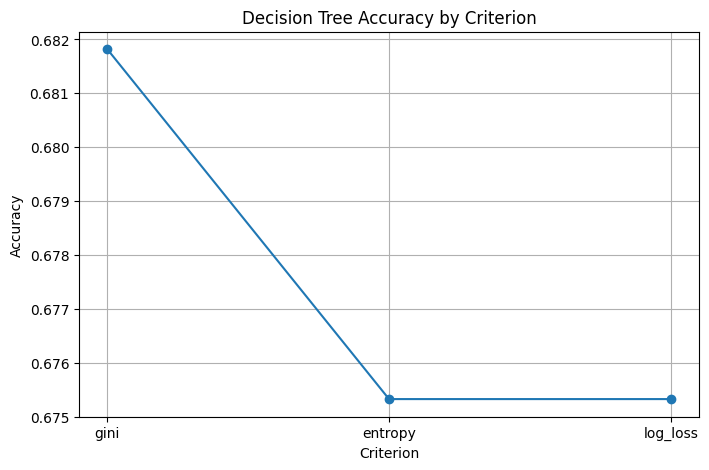

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(results_df['criterion'], results_df['accuracy'], marker='o')
plt.title('Decision Tree Accuracy by Criterion')
plt.xlabel('Criterion')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [20]:
for c in criteria:
    print('\nCriterion:', c)
    
    model = DecisionTreeClassifier(criterion=c, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred))


Criterion: gini
Accuracy: 0.6818181818181818
Confusion Matrix:
[[79 21]
 [28 26]]
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154


Criterion: entropy
Accuracy: 0.6753246753246753
Confusion Matrix:
[[76 24]
 [26 28]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       100
           1       0.54      0.52      0.53        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.68      0.67       154


Criterion: log_loss
Accuracy: 0.6753246753246753
Confusion Matrix:
[[76 24]
 [26 28]]
Classification Report:
              precisi

In [21]:
best_criterion = results_df.sort_values(by='accuracy', ascending=False).iloc[0]['criterion']
print('Best criterion:', best_criterion)

Best criterion: gini


In [22]:
param_grid = {
    'criterion': [best_criterion],
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV score:', grid_search.best_score_)

Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV score: 0.750912968146075


In [23]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print('Optimized Accuracy:', accuracy_score(y_test, y_pred_best))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_best))
print('Classification Report:')
print(classification_report(y_test, y_pred_best))

Optimized Accuracy: 0.6883116883116883
Confusion Matrix:
[[92  8]
 [40 14]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.92      0.79       100
           1       0.64      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.67      0.59      0.58       154
weighted avg       0.68      0.69      0.64       154



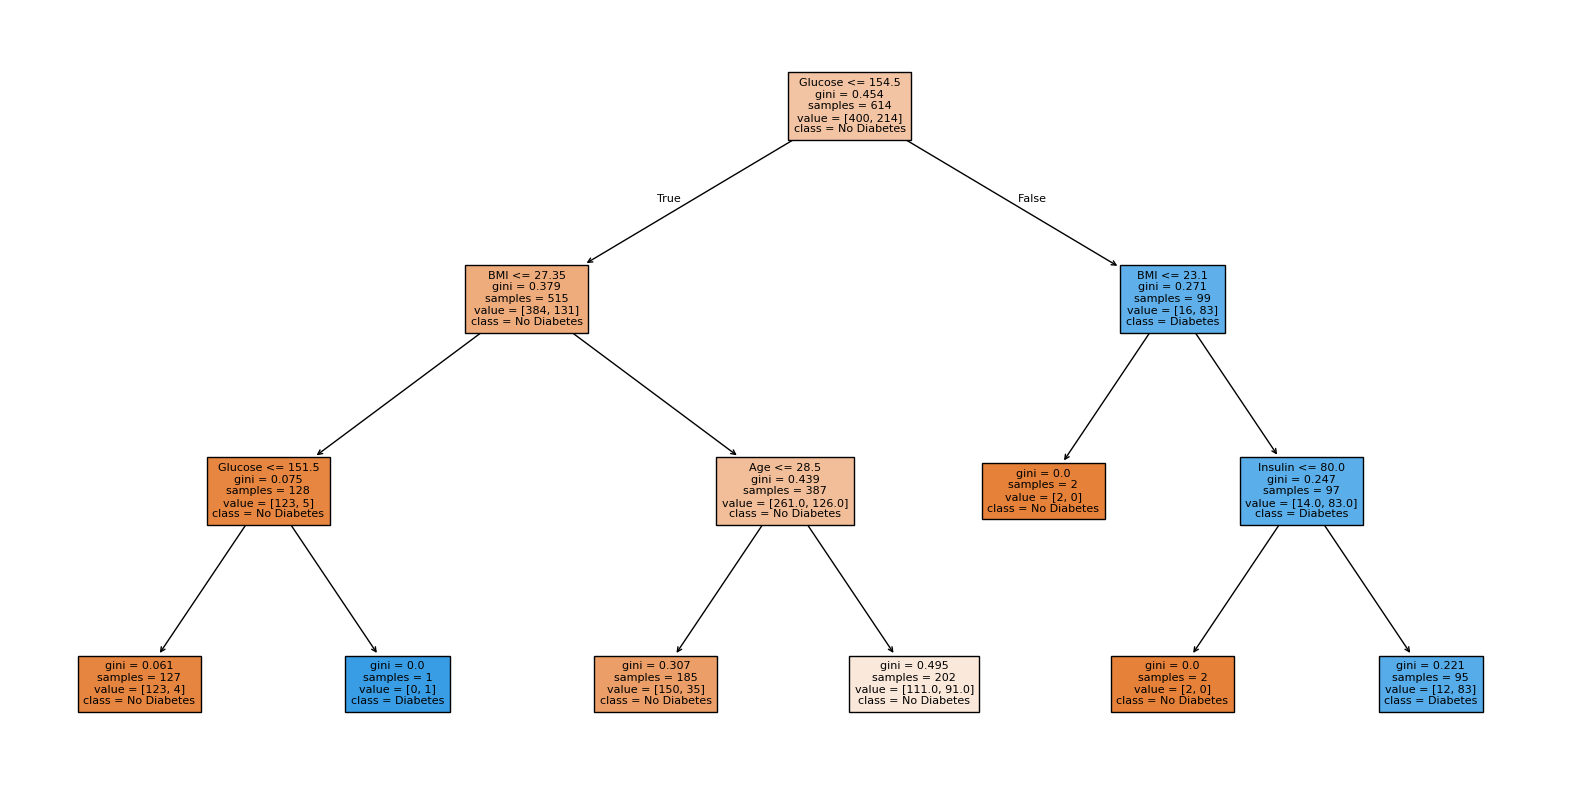

In [24]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    fontsize=8
)
plt.show()

In [25]:
joblib.dump(best_model, 'best_decision_tree_diabetes.joblib')

['best_decision_tree_diabetes.joblib']